## Project 1 

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File. 

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

### **I did not have a group for this project and did it on my own.**

In [ ]:

#Part 1
import pandas as pd
mdf = pd.read_csv('./data/linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("./data/DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

#Merged Data into one complete Dataframe Above

#Documenting Missing Values
missing = df.isna().mean().sort_values(ascending=False)
missing.head(25)
df[["ELIGSTAT","MORTSTAT","PERMTH_INT","RIDAGEEX"]].isna().sum()

   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

ELIGSTAT         0
MORTSTAT      4520
PERMTH_INT    4520
RIDAGEEX       824
dtype: int64

In [ ]:
#Looking up ELIGSTAT, MORTSTAT, PERMTH_INT, AND RIDAGEEX variables in the demographics codebook
print( df[["ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX"]].head() )

   ELIGSTAT  MORTSTAT  PERMTH_INT  RIDAGEEX
0         2       NaN         NaN      31.0
1         1       1.0       177.0     926.0
2         2       NaN         NaN     126.0
3         2       NaN         NaN      23.0
4         1       0.0       244.0     597.0


ELIGSTAT: whether the participant was eligible for mortality follow-up (1 = eligible, 2 = ineligible)

MORTSTAT: mortality status (0 = alive, 1 = deceased)

PERMTH_INT: number of months from the date of the interview to the date of death or end of follow-up

RIDAGEEX: age of the participant at the time of the interview

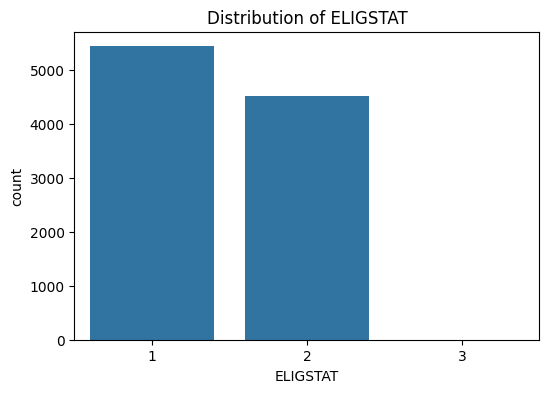

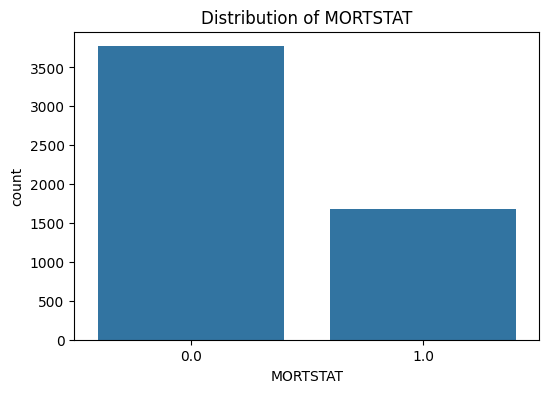

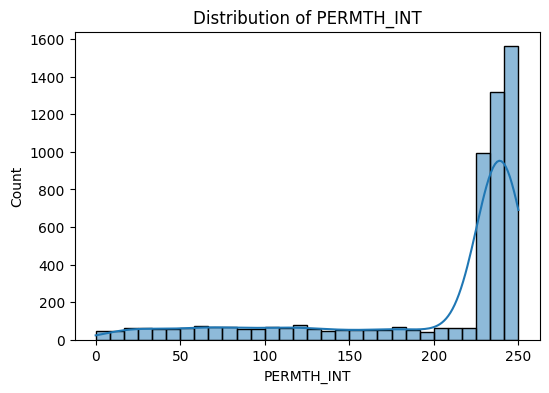

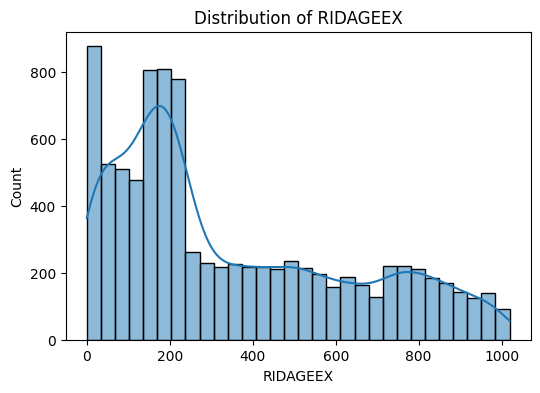

In [ ]:
#Basic EDA and Visualization of the key variables (ELIGSTAT, MORTSTAT, PERMTH_INT, RIDAGEEX)
import matplotlib.pyplot as plt
import seaborn as sns
# Checking for Data Skew
# Distribution of ELIGSTAT
plt.figure(figsize=(6,4))
sns.countplot(x="ELIGSTAT", data=df)
plt.title("Distribution of ELIGSTAT")
plt.show()
# Distribution of MORTSTAT
plt.figure(figsize=(6,4))
sns.countplot(x="MORTSTAT", data=df)
plt.title("Distribution of MORTSTAT")
plt.show()
# Distribution of PERMTH_INT
plt.figure(figsize=(6,4))
sns.histplot(df["PERMTH_INT"], bins=30, kde=True)
plt.title("Distribution of PERMTH_INT")
plt.show()
# Distribution of RIDAGEEX
plt.figure(figsize=(6,4))
sns.histplot(df["RIDAGEEX"], bins=30, kde=True)
plt.title("Distribution of RIDAGEEX")
plt.show()

In [57]:
#Loading NHANES Datasets: Blood Pressure, Body Measurements, and Smoking Questionnaire
bp_df = pd.read_sas("./data/BPX.xpt", format="xport")
bm_df = pd.read_sas("./data/BMX.xpt", format="xport")
sm_df = pd.read_sas("./data/SMQ.xpt", format="xport")
print(bp_df.head())
print(bm_df.head())
print(sm_df.head())

   SEQN  PEASCST1  PEASCTM1      PEASCCT1  BPXCHR  BPQ150A  BPQ150B  BPQ150C  \
0   1.0       1.0     151.0  5.397605e-79   110.0      NaN      NaN      NaN   
1   2.0       1.0     764.0  5.397605e-79     NaN      2.0      2.0      2.0   
2   3.0       1.0     571.0  5.397605e-79     NaN      2.0      2.0      2.0   
3   4.0       1.0      47.0  5.397605e-79   108.0      NaN      NaN      NaN   
4   5.0       1.0     694.0  5.397605e-79     NaN      2.0      2.0      2.0   

   BPQ150D  BPAARM  ...  BPXDI2  BPAEN2  BPXSY3  BPXDI3  BPAEN3  BPXSY4  \
0      NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
1      2.0     1.0  ...    56.0     2.0    98.0    56.0     2.0     NaN   
2      2.0     1.0  ...    64.0     2.0   112.0    62.0     2.0     NaN   
3      NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4      2.0     1.0  ...    84.0     2.0   122.0    82.0     2.0     NaN   

   BPXDI4  BPAEN4  BPXSAR  BPXDAR  
0     NaN     NaN     NaN     Na

In [45]:
import numpy as np
import pandas as pd

# --- Make sure SEQN is numeric everywhere ---
for d in [df, bp_df, bm_df, sm_df]:
    d["SEQN"] = pd.to_numeric(d["SEQN"], errors="coerce")

# --- Merge in the extra NHANES components ---
df = df.merge(bm_df, on="SEQN", how="left")
df = df.merge(bp_df, on="SEQN", how="left")
df = df.merge(sm_df, on="SEQN", how="left")

print("After merging BMX/BPX/SMQ:", df.shape)

After merging BMX/BPX/SMQ: (9965, 467)


In [46]:
# Cleaning
# Convert age to years
df["AGE_YEARS_EXAM"] = pd.to_numeric(df["RIDAGEEX"], errors="coerce") / 12.0

# Blood pressure averages across available readings
sys_cols = [c for c in df.columns if c.startswith("BPXSY")]
dia_cols = [c for c in df.columns if c.startswith("BPXDI")]

df["SBP_MEAN"] = df[sys_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1) if sys_cols else np.nan
df["DBP_MEAN"] = df[dia_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1) if dia_cols else np.nan

print("Systolic cols:", sys_cols)
print("Diastolic cols:", dia_cols)

# Smoking variables to numeric
for c in ["SMQ020", "SMQ040"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# BMI to numeric
if "BMXBMI" in df.columns:
    df["BMXBMI"] = pd.to_numeric(df["BMXBMI"], errors="coerce")


#Check missing data
# Overall missingness top 25
missing = df.isna().mean().sort_values(ascending=False)
missing.head(25)
# Key variables
key_cols = ["ELIGSTAT","MORTSTAT","PERMTH_INT","AGE_YEARS_EXAM","BMXBMI","SBP_MEAN","DBP_MEAN","SMQ020","SMQ040"]
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].isna().sum().sort_values(ascending=False)

Systolic cols: ['BPXSY1_x', 'BPXSY2_x', 'BPXSY3_x', 'BPXSY4_x', 'BPXSY1_y', 'BPXSY2_y', 'BPXSY3_y', 'BPXSY4_y', 'BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXSY4']
Diastolic cols: ['BPXDI1_x', 'BPXDI2_x', 'BPXDI3_x', 'BPXDI4_x', 'BPXDI1_y', 'BPXDI2_y', 'BPXDI3_y', 'BPXDI4_y', 'BPXDI1', 'BPXDI2', 'BPXDI3', 'BPXDI4']


SMQ040            7666
SMQ020            5088
MORTSTAT          4520
PERMTH_INT        4520
SBP_MEAN          2750
DBP_MEAN          2750
BMXBMI            1503
AGE_YEARS_EXAM     824
ELIGSTAT             0
dtype: int64

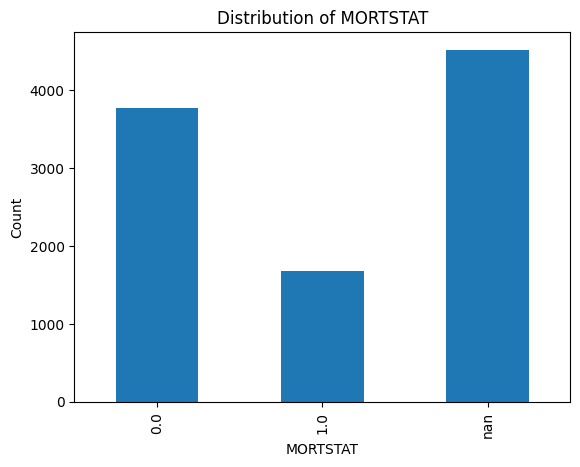

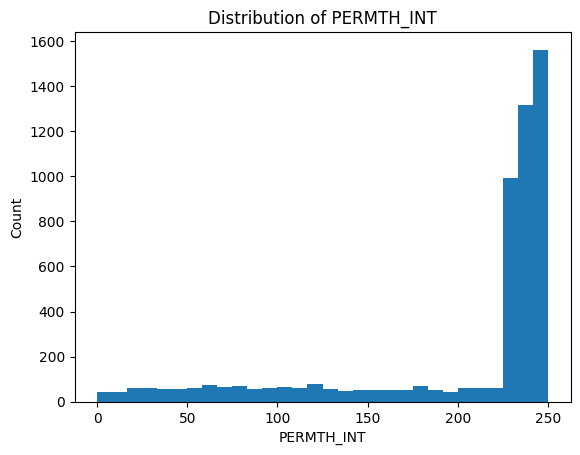

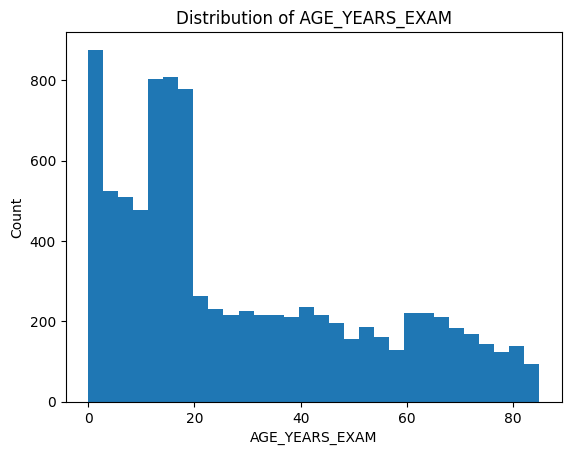

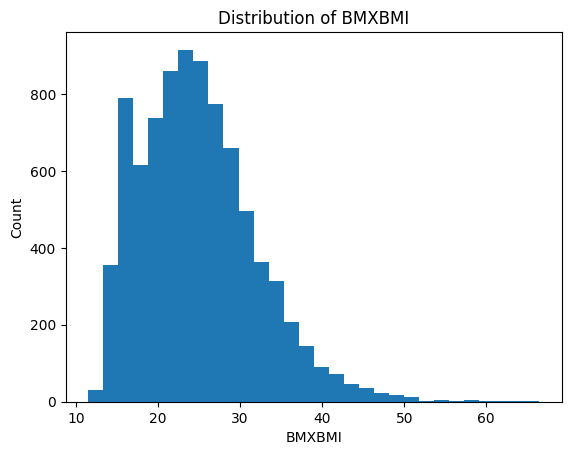

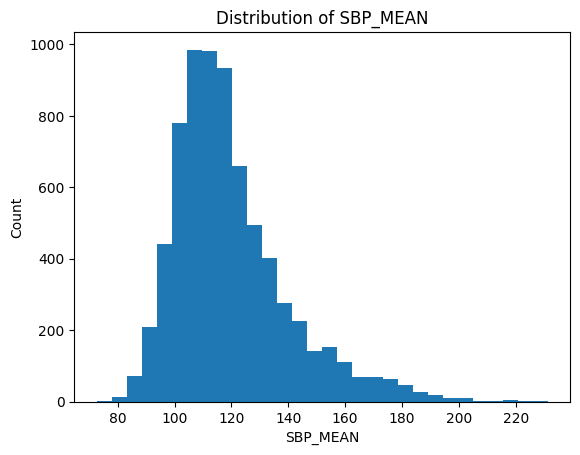

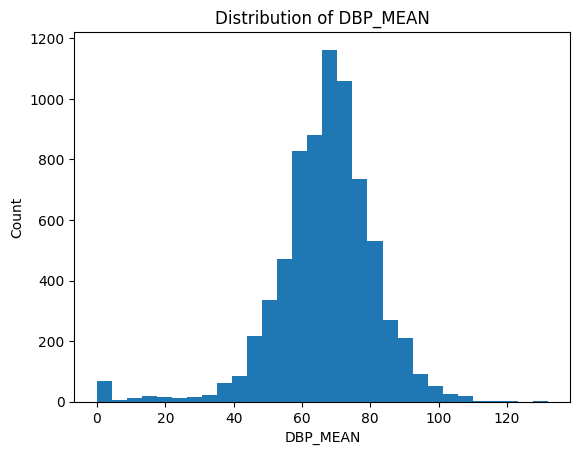

In [47]:
import matplotlib.pyplot as plt

# Targets + main predictors
plot_cols = ["MORTSTAT","PERMTH_INT","AGE_YEARS_EXAM","BMXBMI","SBP_MEAN","DBP_MEAN"]
plot_cols = [c for c in plot_cols if c in df.columns]

for col in plot_cols:
    plt.figure()
    if col in ["MORTSTAT"]:
        df[col].value_counts(dropna=False).sort_index().plot(kind="bar")
        plt.ylabel("Count")
    else:
        plt.hist(df[col].dropna(), bins=30)
        plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()

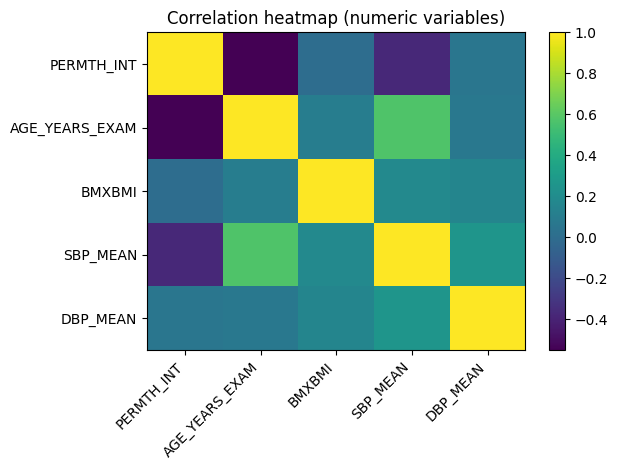

In [48]:
num_for_corr = ["PERMTH_INT","AGE_YEARS_EXAM","BMXBMI","SBP_MEAN","DBP_MEAN"]
num_for_corr = [c for c in num_for_corr if c in df.columns]

corr_df = df[num_for_corr].dropna()
corr = corr_df.corr()

plt.figure()
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(num_for_corr)), num_for_corr, rotation=45, ha="right")
plt.yticks(range(len(num_for_corr)), num_for_corr)
plt.title("Correlation heatmap (numeric variables)")
plt.colorbar()
plt.tight_layout()
plt.show()

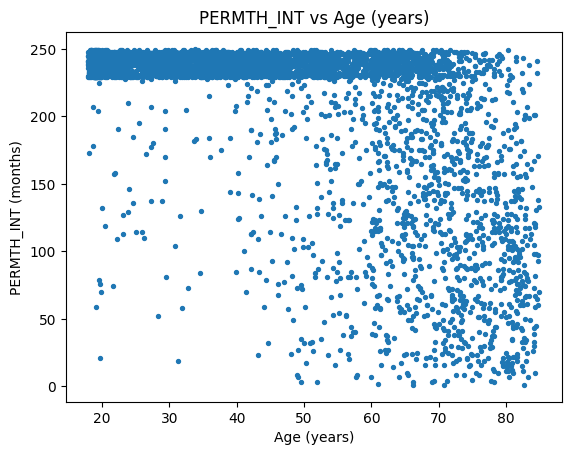

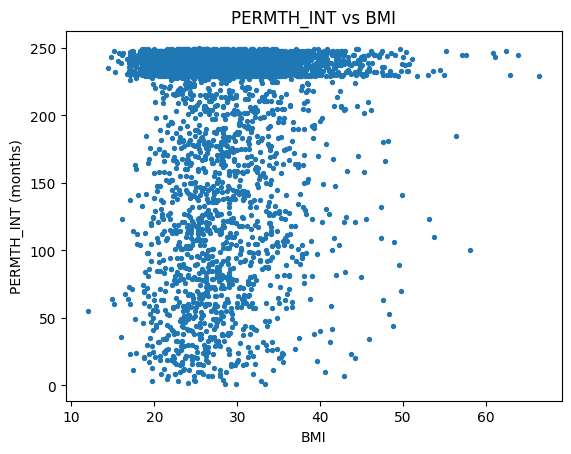

In [49]:
# PERMTH_INT vs Age
plt.figure()
sub = df[["AGE_YEARS_EXAM","PERMTH_INT"]].dropna()
plt.scatter(sub["AGE_YEARS_EXAM"], sub["PERMTH_INT"], s=8)
plt.title("PERMTH_INT vs Age (years)")
plt.xlabel("Age (years)")
plt.ylabel("PERMTH_INT (months)")
plt.show()

# PERMTH_INT vs BMI (if exists)
if "BMXBMI" in df.columns:
    plt.figure()
    sub = df[["BMXBMI","PERMTH_INT"]].dropna()
    plt.scatter(sub["BMXBMI"], sub["PERMTH_INT"], s=8)
    plt.title("PERMTH_INT vs BMI")
    plt.xlabel("BMI")
    plt.ylabel("PERMTH_INT (months)")
    plt.show()

In [50]:
# Age bins for mortality rate
df["AGE_BIN"] = pd.cut(df["AGE_YEARS_EXAM"], bins=[0,18,35,50,65,80,120],
                       labels=["0-18","19-35","36-50","51-65","66-80","80+"])

ct_age = pd.crosstab(df["AGE_BIN"], df["MORTSTAT"])
print("Counts (AGE_BIN x MORTSTAT):\n", ct_age)

age_rate = ct_age.div(ct_age.sum(axis=1), axis=0)
print("\nRow proportions (death rate by age bin):\n", age_rate)

Counts (AGE_BIN x MORTSTAT):
 MORTSTAT   0.0  1.0
AGE_BIN            
0-18        11    0
19-35     1651   59
36-50      983  106
51-65      634  324
66-80      219  647
80+         10  196

Row proportions (death rate by age bin):
 MORTSTAT       0.0       1.0
AGE_BIN                     
0-18      1.000000  0.000000
19-35     0.965497  0.034503
36-50     0.902663  0.097337
51-65     0.661795  0.338205
66-80     0.252887  0.747113
80+       0.048544  0.951456


In [51]:
# Smoking vs Mortality (if SMQ020 exists)
if "SMQ020" in df.columns:
    ct_smoke = pd.crosstab(df["SMQ020"], df["MORTSTAT"])
    print("\nCounts (SMQ020 x MORTSTAT):\n", ct_smoke)
    print("\nRow proportions:\n", ct_smoke.div(ct_smoke.sum(axis=1), axis=0))


Counts (SMQ020 x MORTSTAT):
 MORTSTAT   0.0  1.0
SMQ020             
1.0       1369  928
2.0       1840  725
7.0          1    3
9.0          4    4

Row proportions:
 MORTSTAT       0.0       1.0
SMQ020                      
1.0       0.595995  0.404005
2.0       0.717349  0.282651
7.0       0.250000  0.750000
9.0       0.500000  0.500000


EDA Discussion:
-	MORTSTAT is imbalanced, with more participants alive/censored than deceased, so later classification should consider metrics beyond accuracy (e.g., ROC-AUC / F1).
	
-	PERMTH_INT is strongly right-skewed with a large mass near the maximum follow-up time, which is consistent with censoring (participants alive at the end of follow-up).
	
-	Age (converted from RIDAGEEX months to years) shows a strong relationship with both outcomes: higher mortality rates and generally shorter observed follow-up time for older participants.
	
-	Adding BMI (BMX) and blood pressure (BPX) provides health predictors; smoking variables (SMQ) provide behavioral predictors. These are expected to improve mortality prediction beyond demographics alone.
	
-	Based on these patterns, I plan to use age, sex, race/ethnicity, education, income ratio (DEMO) plus BMI, SBP/DBP averages, and smoking status as predictors for Part 2.

In [52]:
[c for c in df.columns if c.startswith(("BMX","BPX","SMQ"))][:80]

['BMXWT_x',
 'BMXRECUM_x',
 'BMXHEAD_x',
 'BMXHT_x',
 'BMXBMI_x',
 'BMXLEG_x',
 'BMXCALF_x',
 'BMXARML_x',
 'BMXARMC_x',
 'BMXWAIST_x',
 'BMXTHICR_x',
 'BMXTRI_x',
 'BMXSUB_x',
 'BPXCHR_x',
 'BPXPLS_x',
 'BPXDB_x',
 'BPXPULS_x',
 'BPXPTY_x',
 'BPXML1_x',
 'BPXSY1_x',
 'BPXDI1_x',
 'BPXSY2_x',
 'BPXDI2_x',
 'BPXSY3_x',
 'BPXDI3_x',
 'BPXSY4_x',
 'BPXDI4_x',
 'BPXSAR_x',
 'BPXDAR_x',
 'SMQ020_x',
 'SMQ040_x',
 'SMQ050Q_x',
 'SMQ050U_x',
 'SMQ120_x',
 'SMQ140_x',
 'SMQ143_x',
 'SMQ145_x',
 'SMQ150_x',
 'SMQ170_x',
 'SMQ173_x',
 'SMQ175_x',
 'SMQ180_x',
 'SMQ200_x',
 'SMQ205_x',
 'SMQ210_x',
 'SMQ230_x',
 'BMXWT_y',
 'BMXRECUM_y',
 'BMXHEAD_y',
 'BMXHT_y',
 'BMXBMI_y',
 'BMXLEG_y',
 'BMXCALF_y',
 'BMXARML_y',
 'BMXARMC_y',
 'BMXWAIST_y',
 'BMXTHICR_y',
 'BMXTRI_y',
 'BMXSUB_y',
 'BPXCHR_y',
 'BPXPLS_y',
 'BPXDB_y',
 'BPXPULS_y',
 'BPXPTY_y',
 'BPXML1_y',
 'BPXSY1_y',
 'BPXDI1_y',
 'BPXSY2_y',
 'BPXDI2_y',
 'BPXSY3_y',
 'BPXDI3_y',
 'BPXSY4_y',
 'BPXDI4_y',
 'BPXSAR_y',
 'BPXDAR_y',
 'SMQ02

### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

 ### 2.1

 Data description (NHANES 1999–2000 + Linked Mortality File)
-	Each observation is one NHANES participant (unique SEQN).
-	NHANES is a U.S. national health survey collected by the National Center for Health Statistics (CDC/NCHS) to measure the health and nutrition of the U.S. population. The Linked Mortality File links NHANES participants to mortality outcomes using the National Death Index.
-	Outcomes used in this project:
-	MORTSTAT: mortality indicator (deceased vs alive/censored by end of follow-up).
-	PERMTH_INT: follow-up time in months from interview to death or censoring/end of follow-up.

Missing data: Some participants have missing values for questionnaire/exam measures (e.g., smoking questions, blood pressure readings, BMI). This can reduce sample size if rows are dropped; instead, I use imputation for predictors.

Limitations: NHANES is observational, so relationships are correlational (not causal). Mortality follow-up is censored; PERMTH_INT is “time observed” and many participants are alive at end-of-follow-up. In addition, subgroup patterns may reflect confounding (e.g., age and socioeconomic status).


In [35]:
# Age in years (RIDAGEEX is months)
df["AGE_YEARS_EXAM"] = pd.to_numeric(df["RIDAGEEX"], errors="coerce") / 12.0

# Average systolic/diastolic across readings (BPXSY1.., BPXDI1..)
sys_cols = [c for c in df.columns if c.startswith("BPXSY")]
dia_cols = [c for c in df.columns if c.startswith("BPXDI")]

df["SBP_MEAN"] = df[sys_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1) if sys_cols else np.nan
df["DBP_MEAN"] = df[dia_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1) if dia_cols else np.nan

# Ensure outcomes are numeric
df["MORTSTAT"] = pd.to_numeric(df["MORTSTAT"], errors="coerce")
df["PERMTH_INT"] = pd.to_numeric(df["PERMTH_INT"], errors="coerce")

# Ensure common predictors numeric
for c in ["BMXBMI","SMQ020","SMQ040","RIAGENDR","RIDRETH1","DMDEDUC2","INDFMPIR"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

### 2.2

Rationale: Age, smoking, BMI, and blood pressure are strongly linked to mortality risk and general health. Demographics and socioeconomic measures (education and income ratio) often correlate with health access and baseline risk. These variables are interpretable, commonly used in public health risk modeling, and available in NHANES.


In [36]:
#2.2
predictors = [
    "AGE_YEARS_EXAM","RIAGENDR","RIDRETH1","DMDEDUC2","INDFMPIR",
    "BMXBMI","SBP_MEAN","DBP_MEAN","SMQ020","SMQ040"
]
predictors = [c for c in predictors if c in df.columns]
predictors

import matplotlib.pyplot as plt

# Describe table for predictors
df[predictors + ["MORTSTAT","PERMTH_INT"]].describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS_EXAM,9141.0,28.779182,23.627634,4.498004e-80,10.75,19.0,45.833333,84.916667
RIAGENDR,9965.0,1.509985,0.499925,1.000000e+00,1.00,2.0,2.000000,2.000000
RIDRETH1,9965.0,2.561365,1.268133,1.000000e+00,1.00,3.0,4.000000,5.000000
DMDEDUC2,4878.0,2.988520,1.400471,1.000000e+00,2.00,3.0,4.000000,9.000000
INDFMPIR,8482.0,2.175533,1.581478,5.397605e-79,0.88,1.7,3.390000,5.000000
SBP_MEAN,7215.0,119.896512,20.450526,7.266667e+01,106.00,116.0,129.333333,231.333333
DBP_MEAN,7215.0,67.014553,14.681406,5.397605e-79,60.00,68.0,75.333333,132.000000
MORTSTAT,5445.0,0.307622,0.461551,0.000000e+00,0.00,0.0,1.000000,1.000000
PERMTH_INT,5445.0,202.314601,67.137767,0.000000e+00,194.00,235.0,242.000000,250.000000


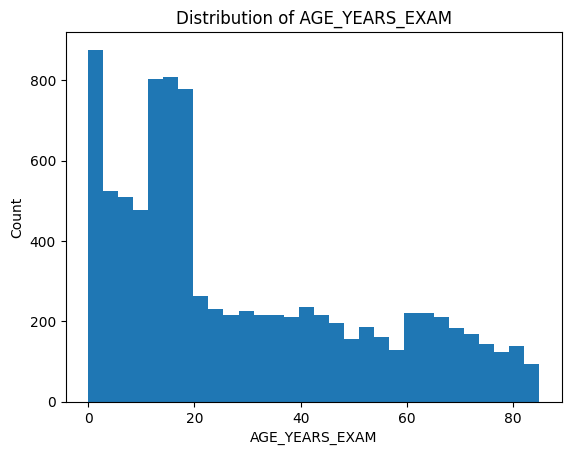

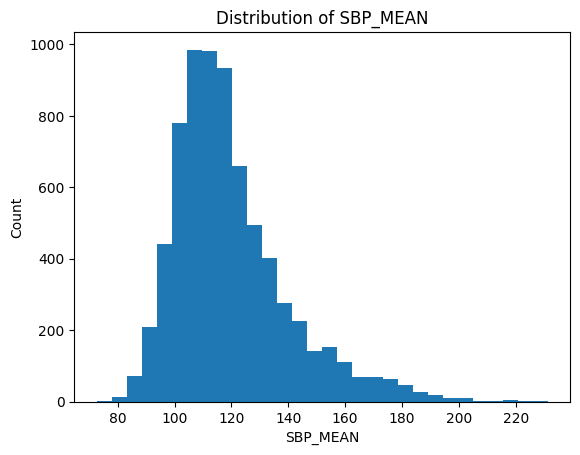

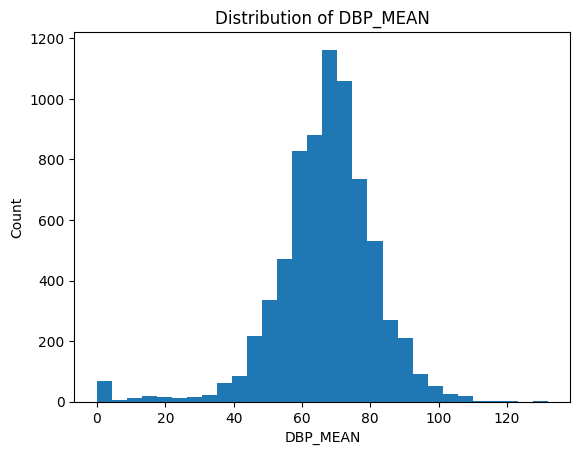

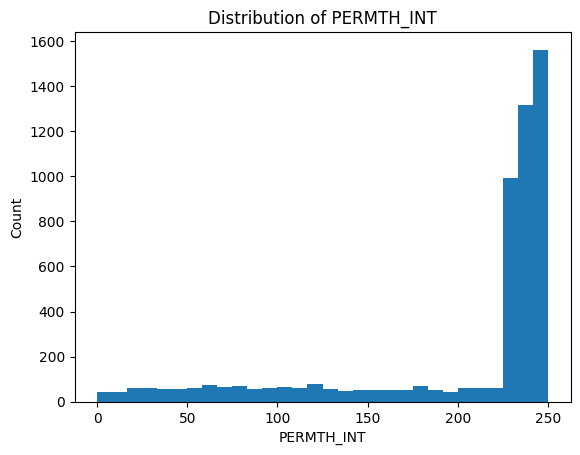

In [ ]:
#2.2

for col in ["AGE_YEARS_EXAM","BMXBMI","SBP_MEAN","DBP_MEAN","PERMTH_INT"]:
    if col in df.columns:
        plt.figure()
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

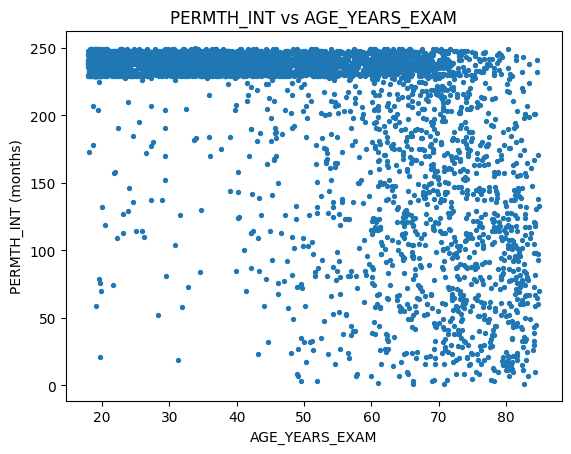

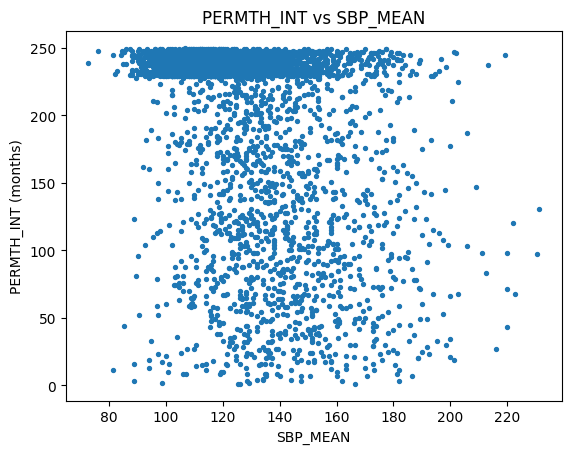

In [38]:
#2.2

for x in ["AGE_YEARS_EXAM","BMXBMI","SBP_MEAN"]:
    if x in df.columns:
        plt.figure()
        sub = df[[x,"PERMTH_INT"]].dropna()
        plt.scatter(sub[x], sub["PERMTH_INT"], s=8)
        plt.title(f"PERMTH_INT vs {x}")
        plt.xlabel(x)
        plt.ylabel("PERMTH_INT (months)")
        plt.show()

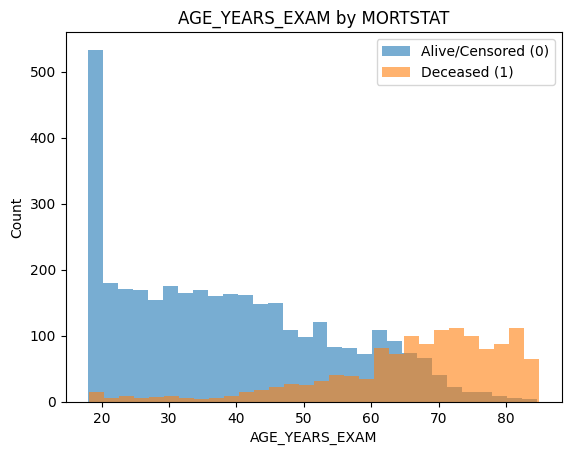

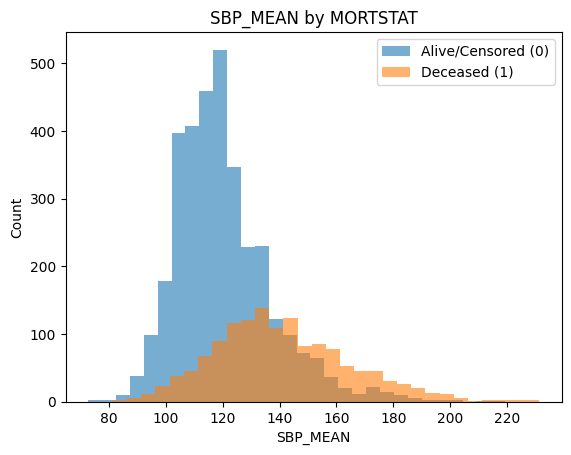

In [39]:
#2.2
# Compare distributions by mortality status
for col in ["AGE_YEARS_EXAM","BMXBMI","SBP_MEAN"]:
    if col in df.columns:
        plt.figure()
        alive = df.loc[df["MORTSTAT"]==0, col].dropna()
        dead  = df.loc[df["MORTSTAT"]==1, col].dropna()
        plt.hist(alive, bins=30, alpha=0.6, label="Alive/Censored (0)")
        plt.hist(dead,  bins=30, alpha=0.6, label="Deceased (1)")
        plt.title(f"{col} by MORTSTAT")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend()
        plt.show()

### 2.3
I selected k using 5-fold cross-validation in GridSearchCV over odd k values (3–51) and both uniform and distance weighting. I chose the model with the best mean CV ROC-AUC because the classes are imbalanced.

In [40]:
#2.3

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Filter to eligible + non-missing target
df_clf = df.copy()
df_clf = df_clf[df_clf["ELIGSTAT"] == 1]
df_clf = df_clf[df_clf["MORTSTAT"].isin([0,1])]

X = df_clf[predictors]
y = df_clf["MORTSTAT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe_clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(3, 52, 2)),
    "knn__weights": ["uniform", "distance"]
}

gs_clf = GridSearchCV(pipe_clf, param_grid=param_grid, cv=5, scoring="roc_auc")
gs_clf.fit(X_train, y_train)

print("Best params:", gs_clf.best_params_)
print("Best CV ROC-AUC:", gs_clf.best_score_)

best_clf = gs_clf.best_estimator_
proba = best_clf.predict_proba(X_test)[:,1]
pred  = best_clf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, pred))
print("Test ROC-AUC:", roc_auc_score(y_test, proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Best params: {'knn__n_neighbors': 51, 'knn__weights': 'uniform'}
Best CV ROC-AUC: 0.8709587591064565
Test Accuracy: 0.8274596182085169
Test ROC-AUC: 0.881821080844408
Confusion Matrix:
 [[866  77]
 [158 261]]
              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88       943
         1.0       0.77      0.62      0.69       419

    accuracy                           0.83      1362
   macro avg       0.81      0.77      0.79      1362
weighted avg       0.82      0.83      0.82      1362



### 2.4
 selected k via 5-fold CV minimizing RMSE. Performance is reported on a held-out test set using RMSE/MAE/R².

In [53]:
#2.4 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df_reg = df.copy()
df_reg = df_reg[df_reg["ELIGSTAT"] == 1]
df_reg = df_reg[df_reg["PERMTH_INT"].notna()]

X = df_reg[predictors]
y = df_reg["PERMTH_INT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

pipe_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

param_grid = {
    "knn__n_neighbors": list(range(3, 52, 2)),
    "knn__weights": ["uniform", "distance"]
}

gs_reg = GridSearchCV(pipe_reg, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error")
gs_reg.fit(X_train, y_train)

print("Best params:", gs_reg.best_params_)
print("Best CV RMSE:", -gs_reg.best_score_)

best_reg = gs_reg.best_estimator_
pred = best_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R^2:", r2)

Best params: {'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
Best CV RMSE: 56.26273971249911
Test RMSE: 54.87194672014344
Test MAE: 37.45151653248266
Test R^2: 0.33245245142123836


### 2.5
How this model could be used:
- The mortality classifier could flag patients with higher predicted risk based on characteristics (age, smoking status, BMI, blood pressure, SES).
- A clinic or public health program could prioritize outreach for smoking cessation, hypertension management, and weight management for high-risk groups.
- The regression model (follow-up time) could help stratify risk and decide intensity of follow-ups (more frequent monitoring for those with shorter predicted follow-up time).

Limitations/risks:
- Predictions are not causal and can encode confounding.
- Risk of unfairness/bias across demographic groups if predictors correlate with structural inequities.
- kNN is sensitive to scaling and missingness; predictions may be unstable in sparse regions of feature space.
- PERMTH_INT includes censoring; interpreting it as “true lifespan” can be misleading.
- Models should not be used alone for medical decisions; they require clinical judgment and careful validation.